# Text Summarization — CNN/DailyMail Dataset
### A beginner NLP project using Python, HuggingFace & BART

**Dataset:** CNN/DailyMail — 300,000+ news articles with human-written summaries  
**Goal:** Automatically shorten a long article into a short summary

> ⚡ **Before running:** Go to `Runtime → Change runtime type → T4 GPU`  
> The BART model is large — GPU makes it much faster!


## Step 1 — Install & Import Libraries

In [1]:
# Install the libraries we need (run once)
!pip install transformers datasets rouge_score nltk sentencepiece -q

  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# HuggingFace — for loading dataset and pretrained model
from datasets import load_dataset
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

# Evaluation
from rouge_score import rouge_scorer

# Extractive summarization tools
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load the Dataset

CNN/DailyMail is built into HuggingFace Datasets — downloads automatically.  
We only load a small sample to keep things fast.

In [3]:
# Load the dataset — version 3.0.0 is the standard
print('Loading CNN/DailyMail dataset...')
dataset = load_dataset('cnn_dailymail', '3.0.0')

print('Done!')
print(f"Training articles:   {len(dataset['train']):,}")
print(f"Validation articles: {len(dataset['validation']):,}")
print(f"Test articles:       {len(dataset['test']):,}")

Loading CNN/DailyMail dataset...


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Done!
Training articles:   287,113
Validation articles: 13,368
Test articles:       11,490


In [4]:
# Convert a small sample to a DataFrame so it is easier to work with
# 1000 articles is enough for EDA and evaluation
sample_size = 1000
df = pd.DataFrame(dataset['test'].select(range(sample_size)))

# Rename columns for clarity
df = df.rename(columns={
    'article':   'article',
    'highlights': 'reference_summary'   # these are the human-written summaries
})

print(f'Working with {len(df)} articles')
print(f'Columns: {df.columns.tolist()}')
df.head(2)

Working with 1000 articles
Columns: ['article', 'reference_summary', 'id']


,article,reference_summary,id
0,(CNN)The Palestinian Authority officially beca...,Membership gives the ICC jurisdiction over all...,f001ec5c4704938247d27a44948eebb37ae98d01
1,(CNN)Never mind cats having nine lives. A stra...,"Theia, a bully breed mix, was apparently hit b...",230c522854991d053fe98a718b1defa077a8efef


In [5]:
# Look at one full example
print('=== ARTICLE ===')
print(df['article'].iloc[0][:800], '...')
print()
print('=== HUMAN SUMMARY ===')
print(df['reference_summary'].iloc[0])

=== ARTICLE ===
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. I ...

=== HUMAN SUMMARY ===
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the mo

---
## Step 3 — Explore the Data (EDA)

In [6]:
# Calculate lengths in words
df['article_words']  = df['article'].apply(lambda x: len(x.split()))
df['summary_words']  = df['reference_summary'].apply(lambda x: len(x.split()))
df['summary_sentences'] = df['reference_summary'].apply(
    lambda x: len(sent_tokenize(x))
)
df['compression_ratio'] = df['summary_words'] / df['article_words']

print('Article word count:')
print(df['article_words'].describe().round(1))
print()
print('Summary word count:')
print(df['summary_words'].describe().round(1))
print()
print(f'Average compression ratio: {df["compression_ratio"].mean():.2%}')
print('(summaries are on average X% as long as the original article)')

Article word count:
count    1000.0
mean      623.0
std       348.8
min        73.0
25%       338.0
50%       566.0
75%       841.5
max      1750.0
Name: article_words, dtype: float64

Summary word count:
count    1000.0
mean       34.5
std         9.7
min        14.0
25%        27.0
50%        34.0
75%        41.0
max        80.0
Name: summary_words, dtype: float64

Average compression ratio: 7.56%
(summaries are on average X% as long as the original article)


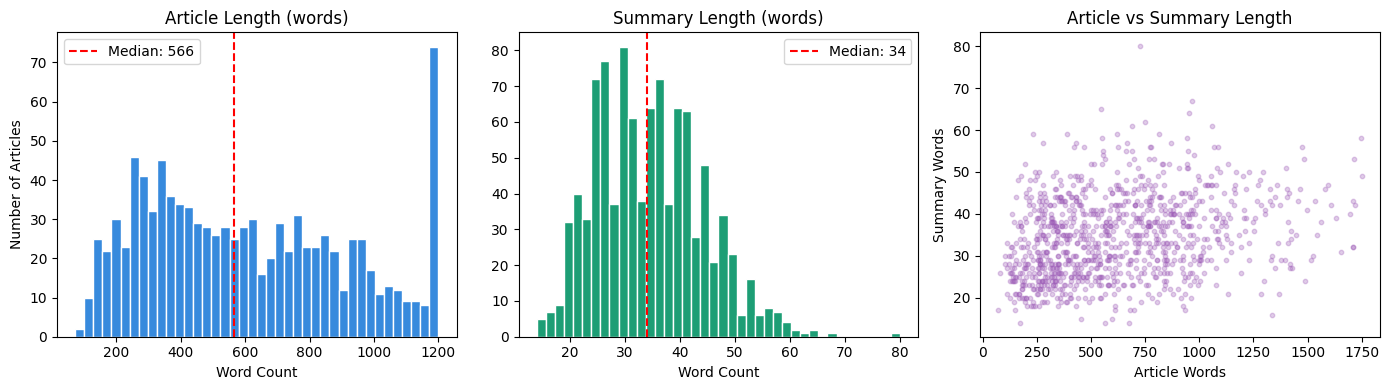

In [7]:
# Plot article vs summary length distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['article_words'].clip(upper=1200), bins=40,
             color='#378ADD', edgecolor='white')
axes[0].set_title('Article Length (words)', fontsize=12)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Articles')
axes[0].axvline(df['article_words'].median(), color='red', linestyle='--',
                label=f'Median: {int(df["article_words"].median())}')
axes[0].legend()

axes[1].hist(df['summary_words'], bins=40,
             color='#1D9E75', edgecolor='white')
axes[1].set_title('Summary Length (words)', fontsize=12)
axes[1].set_xlabel('Word Count')
axes[1].axvline(df['summary_words'].median(), color='red', linestyle='--',
                label=f'Median: {int(df["summary_words"].median())}')
axes[1].legend()

axes[2].scatter(df['article_words'], df['summary_words'],
                alpha=0.3, color='#9B59B6', s=10)
axes[2].set_title('Article vs Summary Length', fontsize=12)
axes[2].set_xlabel('Article Words')
axes[2].set_ylabel('Summary Words')

plt.tight_layout()
plt.show()

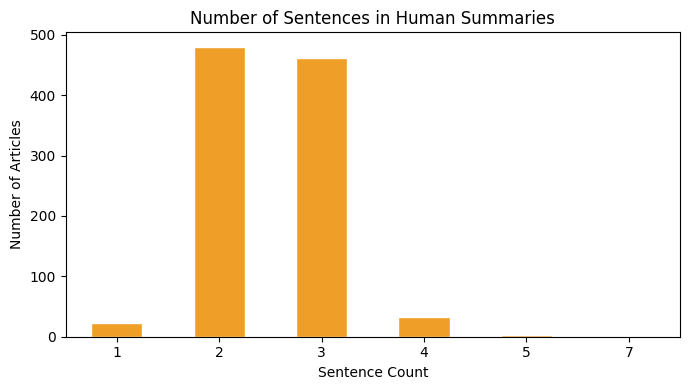

Most summaries have 2 sentences


In [8]:
# How many sentences are in each human-written summary?
plt.figure(figsize=(7, 4))
df['summary_sentences'].value_counts().sort_index().plot(
    kind='bar', color='#EF9F27', edgecolor='white'
)
plt.title('Number of Sentences in Human Summaries', fontsize=12)
plt.xlabel('Sentence Count')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Most summaries have {df["summary_sentences"].mode()[0]} sentences')

---
## Step 4 — Extractive Summarization (TF-IDF Baseline)

**Idea:** Score every sentence by how important its words are using TF-IDF.  
Pick the top N sentences — no new words are generated, just selected.

Think of it like highlighting the most important lines in a textbook.

In [9]:
def extractive_summarize(text, num_sentences=3):
    """
    Summarize text by picking the top N most important sentences.
    Uses TF-IDF to score each sentence.
    """
    # Split the article into individual sentences
    sentences = sent_tokenize(text)

    # Need at least num_sentences sentences to summarize
    if len(sentences) <= num_sentences:
        return text

    # Score each sentence using TF-IDF
    # TF-IDF gives higher scores to sentences with important, unique words
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)

    # Each sentence's score = sum of its word TF-IDF scores
    sentence_scores = tfidf_matrix.sum(axis=1).A1

    # Pick the top N sentence indices
    top_indices = sentence_scores.argsort()[-num_sentences:][::-1]

    # Sort by original position so the summary reads naturally
    top_indices = sorted(top_indices)

    # Join the selected sentences
    summary = ' '.join([sentences[i] for i in top_indices])
    return summary

print('Extractive summarizer ready!')

Extractive summarizer ready!


In [10]:
# Try it on one article
sample_article = df['article'].iloc[0]

extractive_summary = extractive_summarize(sample_article, num_sentences=3)

print('=== ORIGINAL ARTICLE (first 400 chars) ===')
print(sample_article[:400], '...')
print()
print('=== EXTRACTIVE SUMMARY (3 sentences) ===')
print(extractive_summary)
print()
print('=== HUMAN REFERENCE SUMMARY ===')
print(df['reference_summary'].iloc[0])

=== ORIGINAL ARTICLE (first 400 chars) ===
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also acce ...

=== EXTRACTIVE SUMMARY (3 sentences) ===
The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." "As Palestine formally becomes a State Party to the Rome Statute today, the world is also a step closer to ending a long era of impunity and injustice," he said, according to an ICC news release. "Governments seeking to penalize Palestine for joining the ICC should immediately end t

In [11]:
# Generate extractive summaries for all 1000 articles
# (this runs fast — no GPU needed)
print('Generating extractive summaries...')
df['extractive_summary'] = df['article'].apply(
    lambda x: extractive_summarize(x, num_sentences=3)
)
print('Done!')

Generating extractive summaries...
Done!


---
## Step 5 — Abstractive Summarization (BART)

**Idea:** Use a pretrained AI model to *generate* a summary in its own words.  
We use `facebook/bart-large-cnn` — a model specifically trained on this dataset.

Unlike extractive, BART can:
- Combine ideas from different parts of the article
- Rephrase things more clearly
- Write in a natural, fluent style

In [19]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

MODEL_NAME = 'facebook/bart-large-cnn'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bart_model = bart_model.to(device)
bart_model.eval()

def summarizer(text_input, max_length=130, min_length=30, **kwargs):
    """Drop-in replacement for pipeline — works with all transformers versions."""
    if isinstance(text_input, list):
        text_input = text_input[0]
    inputs = tokenizer(
        text_input, return_tensors='pt',
        max_length=1024, truncation=True
    ).to(device)
    with torch.no_grad():
        summary_ids = bart_model.generate(
            inputs['input_ids'],
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            early_stopping=True
        )
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return [{'summary_text': summary}]

print('BART model loaded! Device:', device)

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

BART model loaded! Device: cuda


In [20]:
# Try BART on one article first
bart_summary = summarizer(
    sample_article[:1024],   # BART has a max input length of 1024 tokens
    max_length=130,           # maximum summary length
    min_length=30,            # minimum summary length
    do_sample=False           # deterministic output (no randomness)
)[0]['summary_text']

print('=== ORIGINAL ARTICLE (first 400 chars) ===')
print(sample_article[:400], '...')
print()
print('=== EXTRACTIVE SUMMARY ===')
print(extractive_summary)
print()
print('=== BART ABSTRACTIVE SUMMARY ===')
print(bart_summary)
print()
print('=== HUMAN REFERENCE SUMMARY ===')
print(df['reference_summary'].iloc[0])

=== ORIGINAL ARTICLE (first 400 chars) ===
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also acce ...

=== EXTRACTIVE SUMMARY ===
The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." "As Palestine formally becomes a State Party to the Rome Statute today, the world is also a step closer to ending a long era of impunity and injustice," he said, according to an ICC news release. "Governments seeking to penalize Palestine for joining the ICC should immediately end their pressure,

In [21]:
# Generate BART summaries for 100 articles
# (100 is enough for evaluation — full 1000 would take ~30 mins)
EVAL_SIZE = 100

print(f'Generating BART summaries for {EVAL_SIZE} articles...')
print('This takes about 3-5 minutes on GPU.')

bart_summaries = []
for i, article in enumerate(df['article'].iloc[:EVAL_SIZE]):
    # Truncate to 1024 characters — BART's max input
    result = summarizer(
        article[:1024],
        max_length=130,
        min_length=30,
        do_sample=False
    )[0]['summary_text']
    bart_summaries.append(result)

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{EVAL_SIZE} done...')

df.loc[:EVAL_SIZE-1, 'bart_summary'] = bart_summaries
print('Done!')

Generating BART summaries for 100 articles...
This takes about 3-5 minutes on GPU.
  20/100 done...
  40/100 done...
  60/100 done...
  80/100 done...
  100/100 done...
Done!


---
## Step 6 — Evaluate with ROUGE Scores

**ROUGE** = Recall-Oriented Understudy for Gisting Evaluation  
It compares our generated summary to the human reference summary.

- **ROUGE-1** — overlap of individual words
- **ROUGE-2** — overlap of two-word phrases
- **ROUGE-L** — longest matching sequence of words

Scores range from 0 to 1 — higher is better.

In [22]:
def compute_rouge(predictions, references):
    """
    Compute average ROUGE-1, ROUGE-2, and ROUGE-L scores.
    predictions = list of generated summaries
    references  = list of human reference summaries
    """
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'], use_stemmer=True
    )

    r1_scores, r2_scores, rL_scores = [], [], []

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        r1_scores.append(scores['rouge1'].fmeasure)
        r2_scores.append(scores['rouge2'].fmeasure)
        rL_scores.append(scores['rougeL'].fmeasure)

    return {
        'ROUGE-1': round(np.mean(r1_scores), 4),
        'ROUGE-2': round(np.mean(r2_scores), 4),
        'ROUGE-L': round(np.mean(rL_scores), 4),
    }

print('ROUGE scorer ready!')

ROUGE scorer ready!


In [23]:
EVAL_SIZE = 100

# Evaluate both approaches on the first 100 articles
refs = df['reference_summary'].iloc[:EVAL_SIZE].tolist()
ext  = df['extractive_summary'].iloc[:EVAL_SIZE].tolist()
bart = df['bart_summary'].iloc[:EVAL_SIZE].tolist()

extractive_rouge = compute_rouge(ext,  refs)
bart_rouge       = compute_rouge(bart, refs)

# Show the results as a table
results_df = pd.DataFrame({
    'Extractive (TF-IDF)': extractive_rouge,
    'Abstractive (BART)':  bart_rouge,
})
print('=== ROUGE Score Comparison ===')
print(results_df.to_string())
print()
print('Higher = better. Scores range from 0 to 1.')

=== ROUGE Score Comparison ===
         Extractive (TF-IDF)  Abstractive (BART)
ROUGE-1               0.2486              0.3661
ROUGE-2               0.0874              0.1644
ROUGE-L               0.1708              0.2840

Higher = better. Scores range from 0 to 1.


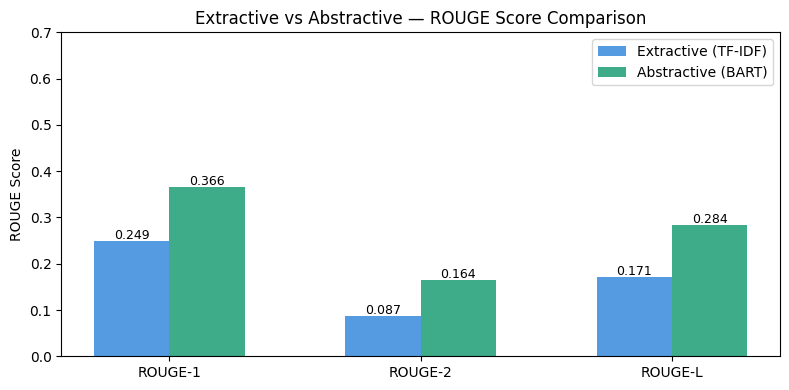

In [24]:
# Plot ROUGE scores side by side
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
ext_vals  = [extractive_rouge[m] for m in metrics]
bart_vals = [bart_rouge[m]       for m in metrics]

x     = np.arange(len(metrics))
width = 0.3

plt.figure(figsize=(8, 4))
bars1 = plt.bar(x - width/2, ext_vals,  width, label='Extractive (TF-IDF)', color='#378ADD', alpha=0.85)
bars2 = plt.bar(x + width/2, bart_vals, width, label='Abstractive (BART)',  color='#1D9E75', alpha=0.85)

for bar in bars1 + bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.xticks(x, metrics)
plt.ylim(0, 0.7)
plt.ylabel('ROUGE Score')
plt.title('Extractive vs Abstractive — ROUGE Score Comparison', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 7 — Compare Both Approaches Side by Side

Numbers are one thing — reading the actual outputs tells the real story.

In [25]:
def show_comparison(idx):
    """Print a full side-by-side comparison for one article."""
    print('=' * 70)
    print(f'ARTICLE #{idx}')
    print('=' * 70)
    print(df['article'].iloc[idx][:500], '...')
    print()
    print('-' * 70)
    print('HUMAN REFERENCE SUMMARY')
    print('-' * 70)
    print(df['reference_summary'].iloc[idx])
    print()
    print('-' * 70)
    print('EXTRACTIVE SUMMARY (TF-IDF — picks sentences from the article)')
    print('-' * 70)
    print(df['extractive_summary'].iloc[idx])
    print()
    print('-' * 70)
    print('ABSTRACTIVE SUMMARY (BART — generates new sentences)')
    print('-' * 70)
    print(df['bart_summary'].iloc[idx])
    print()

# Look at 3 examples
show_comparison(0)
show_comparison(1)
show_comparison(2)

ARTICLE #0
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, includin ...

----------------------------------------------------------------------
HUMAN REFERENCE SUMMARY
----------------------------------------------------------------------
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

----------------------------------------------------------------------
EXTRACTIVE 

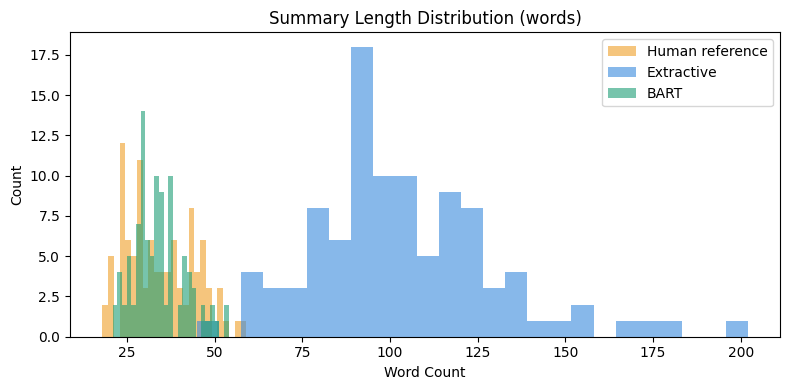

Avg reference length:  34 words
Avg extractive length: 104 words
Avg BART length:       34 words


In [26]:
# Compare summary lengths visually
eval_df = df.iloc[:EVAL_SIZE].copy()
eval_df['extractive_words'] = eval_df['extractive_summary'].apply(lambda x: len(x.split()))
eval_df['bart_words']       = eval_df['bart_summary'].apply(lambda x: len(str(x).split()))
eval_df['reference_words']  = eval_df['reference_summary'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
plt.hist(eval_df['reference_words'],  bins=25, alpha=0.6, color='#EF9F27', label='Human reference')
plt.hist(eval_df['extractive_words'], bins=25, alpha=0.6, color='#378ADD', label='Extractive')
plt.hist(eval_df['bart_words'],       bins=25, alpha=0.6, color='#1D9E75', label='BART')
plt.title('Summary Length Distribution (words)', fontsize=12)
plt.xlabel('Word Count')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Avg reference length:  {eval_df['reference_words'].mean():.0f} words")
print(f"Avg extractive length: {eval_df['extractive_words'].mean():.0f} words")
print(f"Avg BART length:       {eval_df['bart_words'].mean():.0f} words")

---
## Step 8 — Summarise Your Own Text!

Paste any article or long piece of text and get both types of summary.

In [27]:
def summarise(text, num_sentences=3):
    """
    Summarise any text using both approaches.
    text          = the article or passage you want to summarise
    num_sentences = how many sentences for the extractive summary
    """
    print('=' * 60)
    print('INPUT TEXT')
    print('=' * 60)
    print(text[:400], '...' if len(text) > 400 else '')
    print(f'\n({len(text.split())} words)')

    # Extractive
    ext = extractive_summarize(text, num_sentences=num_sentences)
    print()
    print('-' * 60)
    print('EXTRACTIVE SUMMARY (picks sentences from your text)')
    print('-' * 60)
    print(ext)
    print(f'({len(ext.split())} words)')

    # BART abstractive
    bart_out = summarizer(
        text[:1024],
        max_length=130,
        min_length=30,
        do_sample=False
    )[0]['summary_text']

    print()
    print('-' * 60)
    print('ABSTRACTIVE SUMMARY — BART (generates new sentences)')
    print('-' * 60)
    print(bart_out)
    print(f'({len(bart_out.split())} words)')
    print()

print('summarise() function ready!')

summarise() function ready!


In [28]:
# Try it with a sample news article
sample_text = """
Scientists have discovered a new species of deep-sea fish that can survive
at depths of more than 8,000 meters below the ocean surface. The fish,
named Pseudoliparis belyaevi, was found in the Mariana Trench, the deepest
part of the world's oceans. Researchers from the University of Western
Australia and Tokyo University of Marine Science and Technology captured
footage of the snailfish using specially designed landers equipped with
cameras and traps. The discovery is significant because it pushes the known
depth limit for fish further than previously recorded. The snailfish appears
pale and small, about 20 to 30 centimeters long, and lacks the pigmentation
found in fish that live closer to the surface. Scientists believe the fish
adapted to the crushing pressure and complete darkness of the deep ocean
over millions of years. The research was published in the journal Marine
Biology and has sparked excitement in the scientific community about what
other unknown species may still be hiding in the deepest parts of the ocean.
Further expeditions are planned to explore these extreme environments and
collect physical samples for DNA analysis.
"""

summarise(sample_text)

INPUT TEXT

Scientists have discovered a new species of deep-sea fish that can survive
at depths of more than 8,000 meters below the ocean surface. The fish,
named Pseudoliparis belyaevi, was found in the Mariana Trench, the deepest
part of the world's oceans. Researchers from the University of Western
Australia and Tokyo University of Marine Science and Technology captured
footage of the snailfish using spe ...

(181 words)

------------------------------------------------------------
EXTRACTIVE SUMMARY (picks sentences from your text)
------------------------------------------------------------
Researchers from the University of Western
Australia and Tokyo University of Marine Science and Technology captured
footage of the snailfish using specially designed landers equipped with
cameras and traps. The snailfish appears
pale and small, about 20 to 30 centimeters long, and lacks the pigmentation
found in fish that live closer to the surface. The research was published in the journal Ma

In [29]:
# ── Paste YOUR OWN text here! ──────────────────────────────────────────
my_text = """
Paste any long article or passage here and run the cell!
The longer the better — at least 5-6 sentences works best.
"""

summarise(my_text, num_sentences=3)

INPUT TEXT

Paste any long article or passage here and run the cell!
The longer the better — at least 5-6 sentences works best.
 

(22 words)

------------------------------------------------------------
EXTRACTIVE SUMMARY (picks sentences from your text)
------------------------------------------------------------

Paste any long article or passage here and run the cell!
The longer the better — at least 5-6 sentences works best.

(22 words)

------------------------------------------------------------
ABSTRACTIVE SUMMARY — BART (generates new sentences)
------------------------------------------------------------
Paste any long article or passage here and run the cell! The longer the better — at least 5-6 sentences works best. Use the weekly Newsquiz to test your knowledge of stories you saw on CNN.
(36 words)

